# Logistic regression 
In this lab we train a Logistic Regression model with synthetic data for a binary classification problem. Given a labelled dataset of synthetic data, we train a Logistic regression model to find a linear decision boundary between two classes.

In [7]:
# Author: Roberto Doriguzzi-Corin
# Project: Course on Network Intrusion and Anomaly Detection with Machine Learning
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#   http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

SEED = 1

# Create a synthetic dataset with two classes that are linearly separable
X, y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, class_sep=2.0, random_state=SEED)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

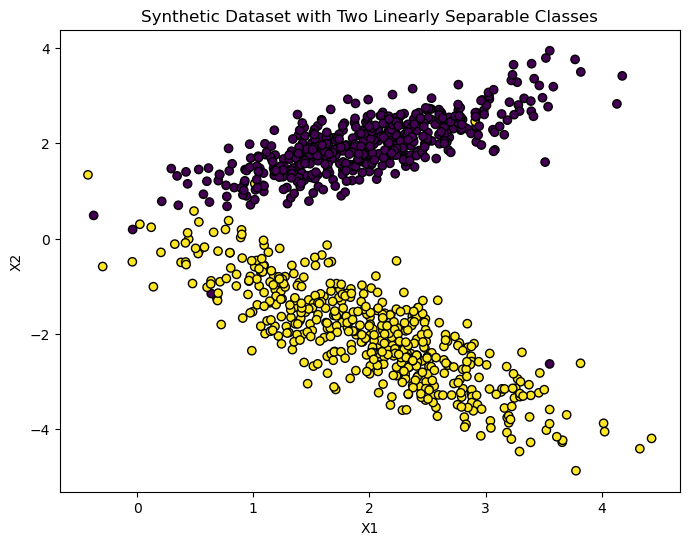

In [8]:
# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Synthetic Dataset with Two Linearly Separable Classes')
plt.show()

In [10]:
# Build the logistic regression model using Keras
model = Sequential()
model.add(Dense(units=1, input_dim=2, activation='sigmoid'))

# Compile the model with binary cross-entropy loss and Adam optimizer
model.compile(loss='binary_crossentropy', optimizer='SGD', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
25/25 [==============================] - 0s 4ms/step - loss: 0.8555 - accuracy: 0.5013 - val_loss: 0.6284 - val_accuracy: 0.5600
Epoch 2/100
25/25 [==============================] - 0s 834us/step - loss: 0.5685 - accuracy: 0.5700 - val_loss: 0.4247 - val_accuracy: 0.6750
Epoch 3/100
25/25 [==============================] - 0s 911us/step - loss: 0.3929 - accuracy: 0.7750 - val_loss: 0.3078 - val_accuracy: 0.9000
Epoch 4/100
25/25 [==============================] - 0s 860us/step - loss: 0.2932 - accuracy: 0.9425 - val_loss: 0.2415 - val_accuracy: 0.9750
Epoch 5/100
25/25 [==============================] - 0s 800us/step - loss: 0.2354 - accuracy: 0.9812 - val_loss: 0.2017 - val_accuracy: 0.9800
Epoch 6/100
25/25 [==============================] - 0s 871us/step - loss: 0.1998 - accuracy: 0.9887 - val_loss: 0.1761 - val_accuracy: 0.9850
Epoch 7/100
25/25 [==============================] - 0s 833us/step - loss: 0.1763 - accuracy: 0.9862 - val_loss: 0.1586 - val_accuracy: 0.9900
E

Decision boundary: -0.16428979 + 0.36292624*X1 + -2.3764234*X2


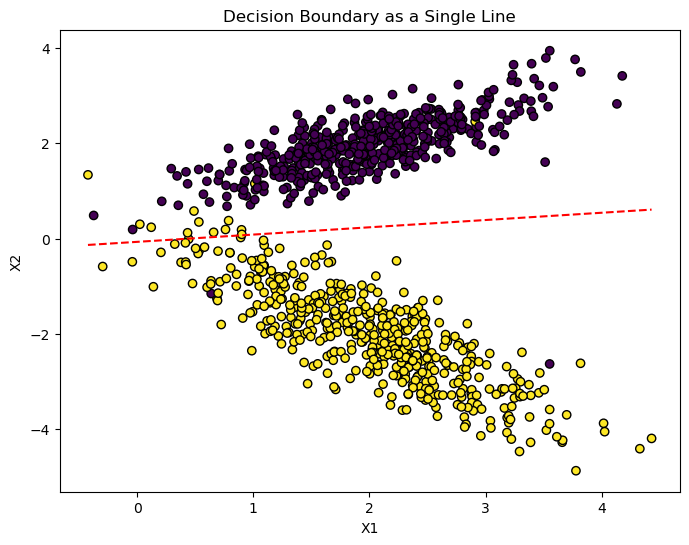

In [11]:
# Get the learned coefficients (weights and bias) from the trained model
weights, bias = model.layers[0].get_weights()
coefficients = [weights[0][0], weights[1][0], bias[0]]

# Print the learned coefficients
print("Decision boundary: " +  str(bias[0]) + " + " + str(weights[0][0]) + "*X1" + " + " + str(weights[1][0]) + "*X2")

# Calculate slope and intercept for the decision boundary line
slope = -coefficients[0] / coefficients[1]
intercept = -coefficients[2] / coefficients[1]

# Plot the data points and decision boundary line
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')

# Plot the decision boundary line
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()
plt.plot([x_min, x_max], [slope * x_min + intercept, slope * x_max + intercept], color='red', linestyle='--')

plt.title('Decision Boundary as a Single Line')
plt.show()

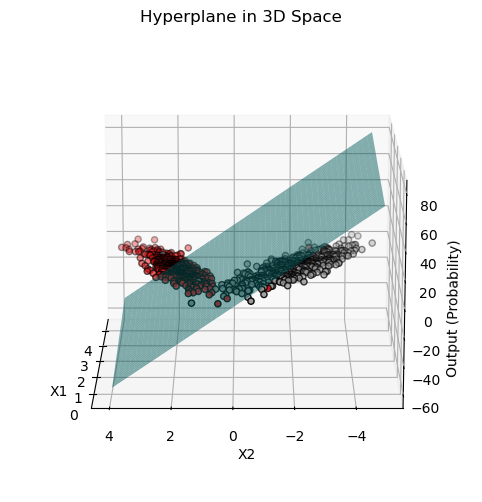

In [14]:
# Generate points for plotting the hyperplane in 3D space
xx, yy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 50),
                     np.linspace(X[:, 1].min(), X[:, 1].max(), 50))
zz = (-coefficients[0] * xx - coefficients[1] * yy - coefficients[2]) / coefficients[2]

# Plot the hyperplane in 3D space
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx, yy, zz, color='c', alpha=0.5)
ax.scatter(X[:, 0], X[:, 1], y, c=y, edgecolors='k', cmap=plt.cm.Set1)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Output (Probability)')
ax.set_title('Hyperplane in 3D Space')

ax.view_init(elev=15, azim=180)  # Elev: Elevation (up/down), Azim: Azimuthal (rotation around the z axis)
plt.show()

# Logistic regression with polynomial features
Logistic regression can be extended to handle polynomial features by incorporating polynomial terms into the feature space. This technique is known as Polynomial Logistic Regression. It allows the logistic regression model to capture nonlinear relationships between the features and the target variable.

In [15]:
# Author: Roberto Doriguzzi-Corin
# Project: Course on Network Intrusion and Anomaly Detection with Machine Learning
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#   http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from keras.models import Sequential
from keras.layers import Dense

SEED  = 1

# Create a synthetic dataset with two classes that are not linearly separable
X, y = make_circles(n_samples=200, noise=0.1, factor=0.3, random_state=SEED)

# Add polynomial features to the data
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

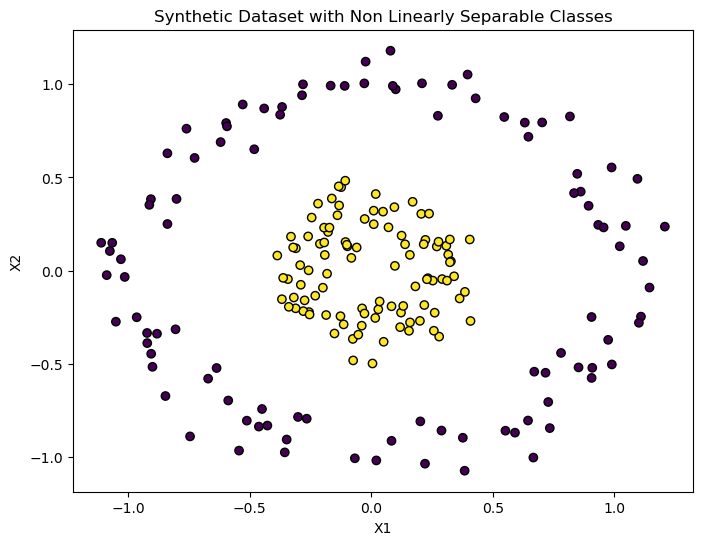

In [18]:
# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Synthetic Dataset with Non Linearly Separable Classes')
plt.show()

In [21]:
# Build the logistic regression model using Keras
model = Sequential()
model.add(Dense(units=1, input_dim=X_poly.shape[1], activation='sigmoid'))

# Compile the model with binary cross-entropy loss and Adam optimizer
model.compile(loss='binary_crossentropy', optimizer='SGD', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=500, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/200
5/5 [==============================] - 0s 16ms/step - loss: 0.9023 - accuracy: 0.3438 - val_loss: 0.8617 - val_accuracy: 0.4500
Epoch 2/200
5/5 [==============================] - 0s 5ms/step - loss: 0.8995 - accuracy: 0.3438 - val_loss: 0.8595 - val_accuracy: 0.4500
Epoch 3/200
5/5 [==============================] - 0s 4ms/step - loss: 0.8968 - accuracy: 0.3375 - val_loss: 0.8573 - val_accuracy: 0.4500
Epoch 4/200
5/5 [==============================] - 0s 3ms/step - loss: 0.8942 - accuracy: 0.3250 - val_loss: 0.8551 - val_accuracy: 0.4500
Epoch 5/200
5/5 [==============================] - 0s 3ms/step - loss: 0.8914 - accuracy: 0.3250 - val_loss: 0.8529 - val_accuracy: 0.4500
Epoch 6/200
5/5 [==============================] - 0s 3ms/step - loss: 0.8887 - accuracy: 0.3313 - val_loss: 0.8508 - val_accuracy: 0.4750
Epoch 7/200
5/5 [==============================] - 0s 3ms/step - loss: 0.8861 - accuracy: 0.3375 - val_loss: 0.8488 - val_accuracy: 0.4500
Epoch 8/200
5/5 [=========

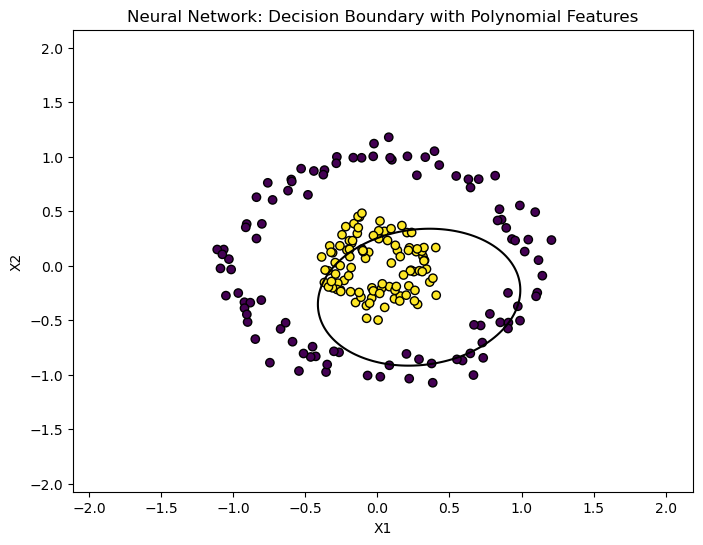

In [22]:
# Plot the decision boundary as a single curve
plt.figure(figsize=(8, 6))
h = .02  # Step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Transform meshgrid points into polynomial features
xx_poly = poly.transform(np.c_[xx.ravel(), yy.ravel()])

# Predict probabilities for each point on the meshgrid
Z = model.predict(xx_poly)
Z = Z.reshape(xx.shape)

# Plot the contour line representing the decision boundary (where probability is 0.5)
plt.contour(xx, yy, Z, levels=[0.5], colors='black')

# Plot the data points
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Neural Network: Decision Boundary with Polynomial Features')
plt.show()